# Projet Classification Styles architecturaux par CNN
**Étudiant :** Assia Mouad / Imane Ait Elmir   
**Filière :** Master ISI   
**Année universitaire :** 2025/2026


## Importation des données depuis la machine locale


In [1]:
from google.colab import files
files.upload()


Saving Dataset.zip to Dataset.zip


## Extraction du dataset à partir du fichier ZIP


In [2]:
import zipfile
import os

zip_path = "/content/Dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extrait !")


Dataset extrait !


## Installation de la bibliothèque pour la division du dataset


In [3]:
!pip install split-folders


In [4]:
!ls /content/dataset/Dataset


'Amazigh architecture'		      'Gothic architecture'
'Ancient Egyptian architecture'       'Moorish architecture'
'Architecture of the Joseon Dynasty'  'Russian Revival architecture'
'Buddhist architecture'


## Division du dataset en ensembles d'entraînement et de validation


In [5]:
import splitfolders

input_folder = "/content/dataset/Dataset"
output_folder = "/content/dataset_split"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.8, 0.2)
)


Copying files: 1934 files [00:00, 2223.15 files/s]


## Chargement et prétraitement des images


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/dataset_split/train"
val_dir = "/content/dataset_split/val"


In [7]:
!pip install split-folders


## Compilation du modèle


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/dataset_split/train"
val_dir = "/content/dataset_split/val"

img_height = 224
img_width = 224
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 1544 images belonging to 7 classes.
Found 390 images belonging to 7 classes.


## Résumé de l’architecture du modèle


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

num_classes = train_gen.num_classes

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,471 (84.86 MB)

 Trainable params: 22,246,471 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

## Analyse de la répartition des classes dans le dataset


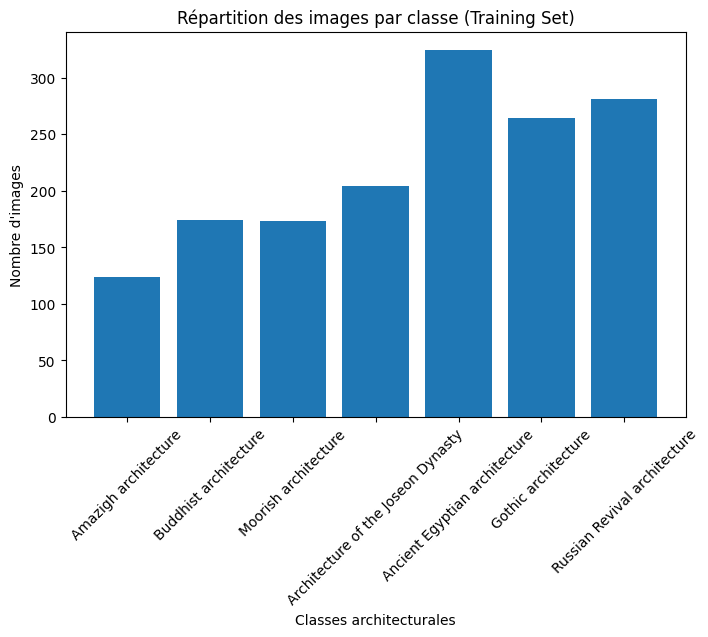

In [10]:
import os
import matplotlib.pyplot as plt

classes = os.listdir(train_dir)
class_counts = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    class_counts.append(len(os.listdir(class_path)))

plt.figure(figsize=(8,5))
plt.bar(classes, class_counts)
plt.title("Répartition des images par classe (Training Set)")
plt.xlabel("Classes architecturales")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.show()


## Entraînement du modèle CNN


In [11]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 33s 452ms/step - accuracy: 0.2346 - loss: 2.5304 - val_accuracy: 0.4513 - val_loss: 1.4477
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 351ms/step - accuracy: 0.5210 - loss: 1.3337 - val_accuracy: 0.5641 - val_loss: 1.2359
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 354ms/step - accuracy: 0.6233 - loss: 1.0692 - val_accuracy: 0.6205 - val_loss: 1.1386
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 346ms/step - accuracy: 0.6628 - loss: 0.9194 - val_accuracy: 0.5744 - val_loss: 1.1839
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 306ms/step - accuracy: 0.6948 - loss: 0.7985 - val_accuracy: 0.6846 - val_loss: 0.9774
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 345ms/step - accuracy: 0.8045 - loss: 0.5756 - val_accuracy: 0.6385 - val_loss: 1.0735
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.8331 - loss: 0.4734 - val_accuracy: 0.6359 - val_loss: 1.2615
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 292ms/step - accuracy: 0.8645 - loss: 0.3934 - val_accu

## Évolution de la précision et de la perte du modèle


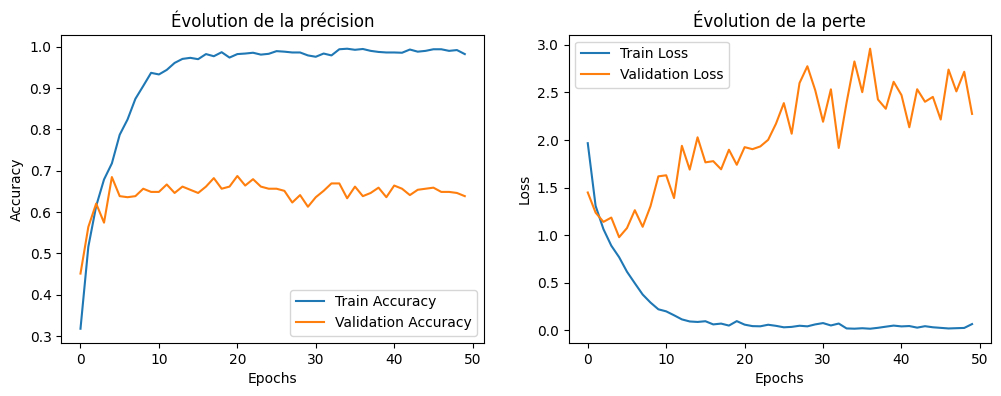

In [12]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Évolution de la précision")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Évolution de la perte")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [13]:
model.save("mydata.h5")
print("Modèle sauvegardé !")


Modèle sauvegardé !


## Tests du modèle sur plusieurs images


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step


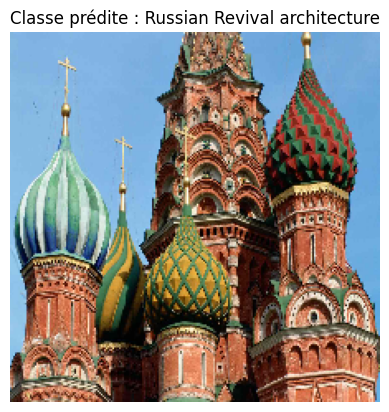

Classe prédite : Russian Revival architecture


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/testrussian.jpg"   


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


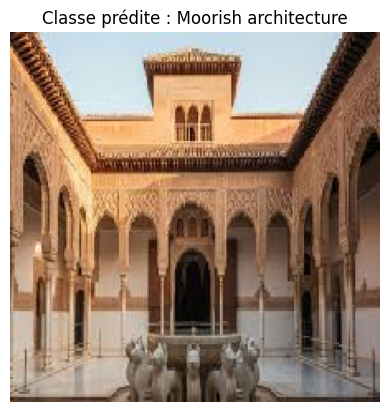

Classe prédite : Moorish architecture


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = "/content/testmoorish.jpg"   


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


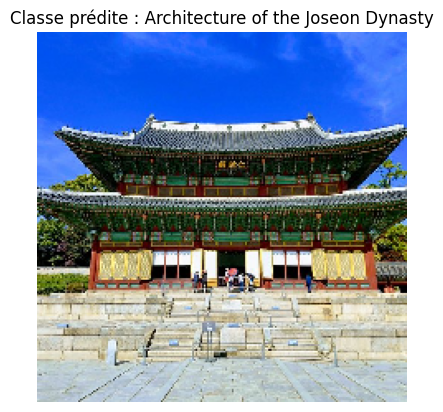

Classe prédite : Architecture of the Joseon Dynasty


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = "/content/testkora.jpg"  


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


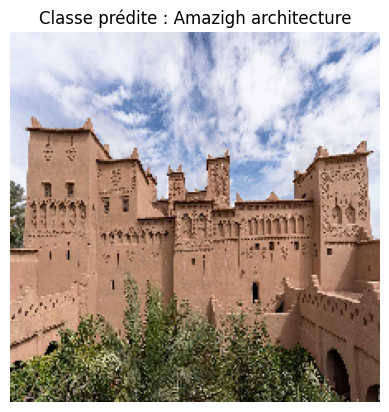

Classe prédite : Amazigh architecture


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = "/content/testamazigh.jpg"  


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


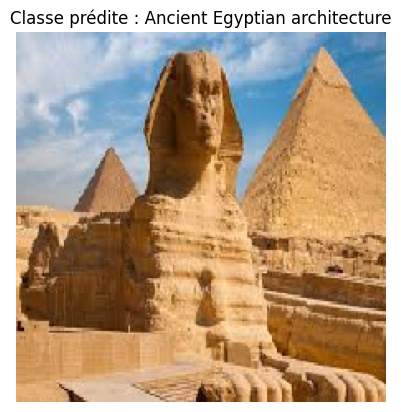

Classe prédite : Ancient Egyptian architecture


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = "/content/testegypt.jpg"   


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


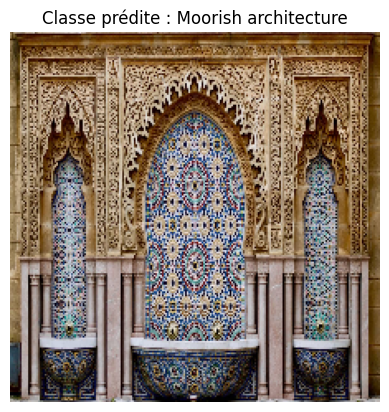

Classe prédite : Moorish architecture


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = "/content/testmoorish2.jpg"   


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


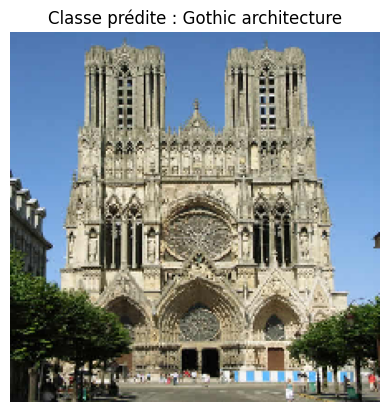

Classe prédite : Gothic architecture


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = "/content/testgothic.jpg"  


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


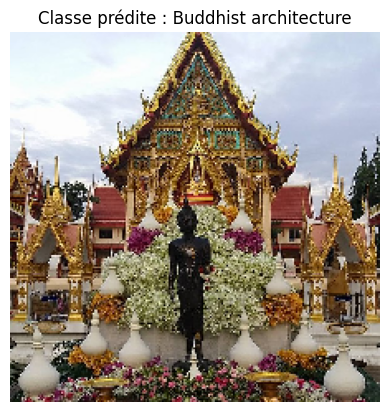

Classe prédite : Buddhist architecture


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


img_path = "/content/testbuddhist.jpg"  


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_preprocessed = np.expand_dims(img_array, axis=0) / 255.


pred = model.predict(img_preprocessed)
class_idx = np.argmax(pred)

predicted_class = list(train_gen.class_indices.keys())[class_idx]


plt.imshow(img)
plt.title(f"Classe prédite : {predicted_class}")
plt.axis('off')
plt.show()

print("Classe prédite :", predicted_class)

## Conclusion

Ce projet a permis de concevoir un modèle CNN capable de classifier des images
architecturales avec des résultats satisfaisants.  
Il constitue une bonne base pour des améliorations futures comme le Transfer Learning.
